In [2]:
import os
import sys
import pandas as pd
import numpy as np

In [2]:
df_positivos = pd.read_csv('../data/processed/positivos.csv')
df_negativos = pd.read_csv('../data/processed/negativos.csv')

In [4]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../scripts")))

In [34]:


# Añadir las columnas necesarias
df_negativos["Departamento"] = np.nan      # o podrías usar "Simulado"
df_negativos["Municipio"] = np.nan
df_negativos["Altura_msnm"] = np.nan
df_negativos["Tipo_Movimiento"] = "Sin deslizamiento"  # Esto puede ser útil para debugging

# Confirmar columnas finales
print("Columnas finales:", df_negativos.columns.tolist())

# Guardar de nuevo (opcional)
df_negativos.to_csv("datos_negativos.csv", index=False)


Columnas finales: ['id_neg', 'Latitud', 'Longitud', 'fecha_evento', 'fecha_clima', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'precipitation_sum', 'relative_humidity_2m_max', 'relative_humidity_2m_min', 'relative_humidity_2m_mean', 'pressure_msl_mean', 'wind_speed_10m_max', 'et0_fao_evapotranspiration', 'target', 'Departamento', 'Municipio', 'Altura_msnm', 'Tipo_Movimiento']


In [10]:
#prueba 1
from features import process_landslide_data
features_df = process_landslide_data('../data/processed/datos_negativos.csv')

Cargando datos...
Datos cargados: 504000 filas, 16800 eventos únicos
Calculando features por evento...
Features calculados: 16800 eventos
Número de features: 69


c:\Users\Alexander Sanguino\Desktop\SIATMA\scripts\features.py:209: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby('id').apply(calculate_event_features).reset_index()


In [11]:
features_df.to_csv('landslide_features_neg.csv', index=False)

In [8]:
features_df.head()  # Mostrar las primeras filas del DataFrame para verificar

,id,precip_sum_1d,precip_sum_2d,precip_sum_3d,precip_sum_5d,precip_sum_7d,precip_sum_10d,precip_sum_15d,precip_sum_30d,precip_max_1d,...,day_sin,day_cos,departamento,municipio,altura_msnm,latitud,longitud,tipo_movimiento,target,fecha_evento
0,1,4.2,8.2,16.0,23.3,31.8,44.5,71.1,128.2,11.6,...,0.858764,0.512371,BOYACÁ,SOMONDOCO,1.642,4.976953,-73.442894,Deslizamiento,1,2025-03-02
1,2,1.8,1.9,3.4,10.0,12.1,14.6,41.8,88.6,9.3,...,-0.880012,-0.474951,BOYACÁ,RONDÓN,1.820,5.359969,-73.199800,Deslizamiento,1,2023-09-03
2,3,19.3,52.8,72.1,82.6,83.3,122.7,141.0,370.8,33.5,...,0.111659,-0.993747,BOYACÁ,SANTANA,1.607,6.039606,-73.492428,Deslizamiento,1,2023-06-26
3,4,15.2,19.4,29.2,34.7,50.4,82.1,104.6,150.6,15.8,...,0.615285,-0.788305,BOYACÁ,SIACHOQUE,3.167,5.494425,-73.220261,Deslizamiento,1,2023-05-25
4,5,24.7,36.7,73.1,135.0,157.8,249.4,436.9,695.6,48.6,...,0.628763,-0.777597,BOYACÁ,NaN,1.918,5.916550,-73.493317,Deslizamiento,1,2023-05-24


In [39]:
# Cargar features
positivos = pd.read_csv("landslide_features_pos.csv")
negativos = pd.read_csv("landslide_features_neg.csv")


In [55]:
negativos = negativos.drop(columns=["municipio_x"], errors="ignore")


In [50]:
# Crear un diccionario lat/lon → altura
alturas_dict = positivos.drop_duplicates(subset=["latitud", "longitud"])[["latitud", "longitud", "altura_msnm"]]

# Hacer un merge para agregar altura
negativos = negativos.merge(alturas_dict, on=["latitud", "longitud"], how="left")


In [51]:
negativos.head()  # Mostrar las primeras filas del DataFrame para verificar

,id,precip_sum_1d,precip_sum_2d,precip_sum_3d,precip_sum_5d,precip_sum_7d,precip_sum_10d,precip_sum_15d,precip_sum_30d,precip_max_1d,...,day_cos,municipio_x,latitud,longitud,tipo_movimiento,target,fecha_evento,municipio,departamento,altura_msnm
0,1000_month_2007,4.8,11.4,14.2,20.3,21.6,26.1,64.6,166.3,13.6,...,-0.284359,NaN,5.078686,-73.423603,Sin deslizamiento,0,2007-04-19,TENZA,BOYACÁ,1.564
1,1000_month_2015,7.0,15.9,17.3,25.4,33.0,44.3,62.0,258.9,70.8,...,-0.284359,NaN,5.078686,-73.423603,Sin deslizamiento,0,2015-04-19,TENZA,BOYACÁ,1.564
2,1000_month_2021,8.7,13.5,16.2,22.7,41.8,52.8,84.0,191.9,25.7,...,-0.284359,NaN,5.078686,-73.423603,Sin deslizamiento,0,2021-04-19,TENZA,BOYACÁ,1.564
3,1001_month_2000,14.9,31.7,41.9,96.2,147.7,202.7,330.4,506.5,37.1,...,-0.200891,NaN,2.453000,-76.622417,Sin deslizamiento,0,2000-04-13,POPAYÁN,CAUCA,1.700
4,1001_month_2002,0.1,3.5,6.9,11.6,55.5,163.4,284.6,633.1,41.5,...,-0.183998,NaN,2.453000,-76.622417,Sin deslizamiento,0,2002-04-13,POPAYÁN,CAUCA,1.700


In [62]:
# Verifica que tengan las mismas columnas
assert set(positivos.columns) == set(negativos.columns), "¡Las columnas no coinciden!"
# Concatenar
df = pd.concat([positivos, negativos], ignore_index=True)

print(df['target'].value_counts())


target
0    16800
1     5631
Name: count, dtype: int64


In [70]:
df.to_csv("../data/landslide_dataset_full.csv", index=False)


In [78]:
X = df.drop(columns=["target", "id", "fecha_evento","departamento","municipio","tipo_movimiento"])  # deja fuera columnas no útiles
y = df["target"]


In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Separar features y target
#X = df.drop(columns=["target", "id", "fecha_evento","departamento","municipio","tipo_movimiento"])  # Excluye columnas no numéricas
y = df['target']

# Entrenamiento-prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Entrenar modelo con balanceo de clases
modelo = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Evaluar
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.82      1.00      0.90      3361
           1       0.99      0.33      0.49      1126

    accuracy                           0.83      4487
   macro avg       0.90      0.66      0.70      4487
weighted avg       0.86      0.83      0.80      4487



In [ ]:
importancias = modelo.feature_importances_
features_ordenados = pd.Series(importancias, index=X.columns).sort_values(ascending=False)

# Mostrar como lista para copiar y pegar
lista_importantes = list(features_ordenados.index)
for feature in lista_importantes:
    print(feature)

In [98]:
# Lista de features a eliminar por baja importancia
features_a_eliminar = [
    'days_rain_gt_50mm_7d',
    'days_rain_gt_20mm_7d',
    'days_rain_gt_10mm_7d',
    'days_rain_gt_1mm_7d',
    'days_rain_gt_20mm_15d',
    'days_rain_gt_10mm_15d',
    'days_rain_gt_1mm_15d',
    'days_rain_gt_20mm_30d',
    'days_rain_gt_10mm_30d',
    'days_rain_gt_1mm_30d',
    "month",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos"
]

# Eliminar en train y test
X_train_reducido = X_train.drop(columns=features_a_eliminar, errors='ignore')
X_test_reducido = X_test.drop(columns=features_a_eliminar, errors='ignore')
X = X.drop(columns=features_a_eliminar, errors='ignore')


In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Modelo
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    class_weight='balanced'  # útil si hay desbalance
)

modelo.fit(X_train_reducido, y_train)

# Predicción y evaluación
y_pred = modelo.predict(X_test_reducido)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.88      0.85      3361
           1       0.55      0.45      0.50      1126

    accuracy                           0.77      4487
   macro avg       0.69      0.66      0.67      4487
weighted avg       0.76      0.77      0.76      4487



In [95]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Manejo de desbalanceo con scale_pos_weight
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Modelo XGBoost
modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss'
)

modelo_xgb.fit(X_train, y_train)

# Predicción y evaluación
y_pred = modelo_xgb.predict(X_test)
print(classification_report(y_test, y_pred))


c:\Users\Alexander Sanguino\Desktop\SIATMA\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:37:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.84      0.82      0.83      3361
           1       0.50      0.53      0.51      1126

    accuracy                           0.75      4487
   macro avg       0.67      0.67      0.67      4487
weighted avg       0.75      0.75      0.75      4487



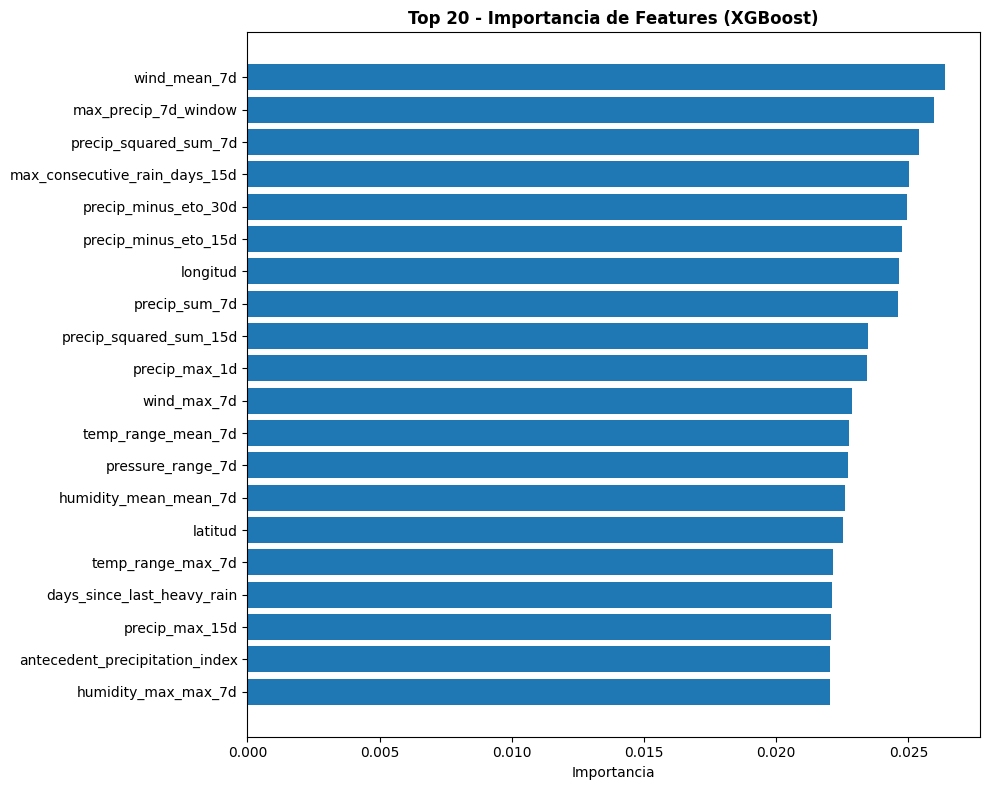

In [96]:
import matplotlib.pyplot as plt

# Suponiendo que ya entrenaste modelo_xgb y tienes X_train
importances = modelo_xgb.feature_importances_
features = X_train.columns

# Convertir a DataFrame y ordenar
feat_imp_df = pd.DataFrame({'feature': features, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

# Graficar las 20 más importantes
plt.figure(figsize=(10, 8))
plt.barh(feat_imp_df['feature'].head(20)[::-1], feat_imp_df['importance'].head(20)[::-1])
plt.title('Top 20 - Importancia de Features (XGBoost)', fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()
